# Non-Uniform Radial Poisson Solver:
# Origin Core Concentration Problem ($r \to 0$)

$$
u(r,\theta)
=
(R^2-r^2)
e^{-\alpha \frac{r^2}{R^2}}
\left(\frac{r}{R}\right)^m
\cos\left(m(\theta-\theta_0)\right)
$$

This manufactured Poisson problem models concentrated core physics (e.g., localized laser heating or central charge distributions) near the origin $r = 0$, satisfying homogeneous Dirichlet boundary conditions $u(R, \theta) = 0$.

### Theoretical Principle & Radial Nonuniformity Motivation:
- **Azimuthal Direction (Uniform is Optimal)**: Equispaced sampling in $\theta$ uniquely achieves exact trigonometric interpolation with optimal spectral accuracy and matrix conditioning ($\,\kappa=1\,$). Nonuniform placement in $\theta$ cannot improve accuracy at fixed $N$. For mode $m=1$, $N=32$ resolves the Fourier coefficients to machine precision (zero angular error).
- **Radial Direction (Nonuniform Beats Uniform at Fixed $M$)**: Radial integration is a local 1D polynomial quadrature rule (Trapezoidal/Simpson) combined with recurrences. Local quadrature truncation error is governed by local derivative behavior. When sharp curvature and excitation concentrate near the origin core, uniform radial spacing under-resolves the central region. Concentrating radial nodes near $r=0$ minimizes total quadrature error for a fixed radial point budget $M$ at **zero computational cost overhead**.

In [5]:
import os
import sys
from pathlib import Path

# ---------------------------------------------------------
# Backend & Environment Configuration
# ---------------------------------------------------------
USE_GPU = False  # Set to True for NVIDIA GPU acceleration

# Auto-detect Google Colab
IN_COLAB = 'google.colab' in sys.modules or os.environ.get('COLAB_GPU') is not None
if IN_COLAB:
    if not os.path.exists('Poisson_Solver'):
        os.system('git clone https://github.com/CharliePyle4/NUFFTRR_Poisson.git')
        if os.path.exists('NUFFTRR_Poisson'):
            os.chdir('NUFFTRR_Poisson')
    os.system('pip install -r requirements.txt -q')
    if USE_GPU:
        os.system('pip install cufinufft -q')

# Dynamic repository root and helper path resolution
repo_root = str(Path.cwd().resolve())
while repo_root and not os.path.exists(os.path.join(repo_root, 'Poisson_Solver')):
    parent = str(Path(repo_root).parent)
    if parent == repo_root:
        break
    repo_root = parent
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

tests_dir = os.path.join(repo_root, 'Tests', 'paper')
if tests_dir not in sys.path:
    sys.path.insert(0, tests_dir)

# Fixed Angular Grid Resolution (Resolves theta mode m=1 to machine precision)
N = 32
num_processors = None    # Number of CPU threads (None = all available cores)
backend_name = 'GPU (NVIDIA CuPy / cuFINUFFT)' if USE_GPU else 'CPU (Multithreaded FINUFFT)'
print('=' * 60)
print(f'  Executing Radial Core Concentration Test Suite (N = {N}) on: {backend_name}')
print('=' * 60)

from nonuniform_radial_helpers import *


  Executing Radial Core Concentration Test Suite (N = 32) on: CPU (Multithreaded FINUFFT)


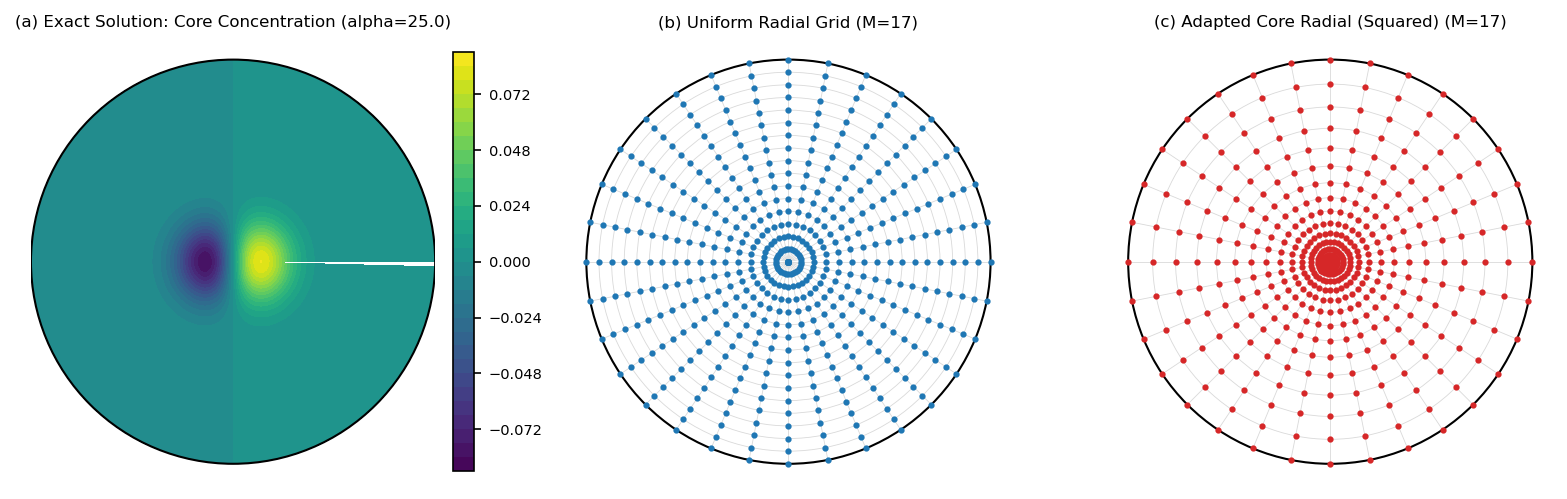

In [6]:
# Problem Setup: Origin Core Concentration (alpha = 25.0, mode = 1)
R = 1.0
mode = 1
alpha_param = 25.0
problem = get_core_concentrated_problem(R=R, mode=mode, alpha_param=alpha_param)

# Journal-style 1 x 3 visualization of solution and radial meshes
plot_solution_and_radial_grids(
    problem=problem,
    N=N,
    M=17,
    primary_kind="squared",
    primary_label="Adapted Core Radial (Squared)"
)


## Radial Refinement ($M$-sweep) Benchmark Study & Performance Profiles

With the angular resolution fixed at $N = 32$, we perform a radial refinement sweep over $M \in \{9, 17, 25, 33, 49, 65, 97, 129, 257\}$.
Tabular benchmarks display **Accuracies first** and **Runtimes last**.

In [7]:
M_dense = [9, 17, 25, 33, 49, 65, 97, 129, 257]
rad_kinds = [
    ("uniform", "Uniform Radial"),
    ("squared", "Adapted Nonuniform (Squared)"),
    ("chebyshev_lobatto", "Chebyshev-Lobatto"),
]

# Execute Radial Grid Sweep for Fixed N = 32
df_fixed_n = run_radial_grid_sweep(problem, N=N, M_values=M_dense, rad_kinds=rad_kinds, quad_rule=2)

# 1. Accuracy Table (Fixed N=32, Varying M) (FIRST)
render_fixed_n_accuracy_table(df_fixed_n, title=f"Table 1: Relative Errors for Fixed N = {N} with Varying Radial Points M")

# 2. Runtime Table (Fixed N=32, Varying M) (LAST)
render_fixed_n_runtime_table(df_fixed_n, title=f"Table 2: Solve Runtimes (ms) for Fixed N = {N} with Varying Radial Points M")


Radial M-sweep (Core Concentration (alpha=25.0)): 100%|██████████| 27/27 [00:00<00:00, 87.91it/s] 


rad_kind,Adapted Nonuniform (Squared),Chebyshev-Lobatto,Uniform Radial
M,,,
9,2.10 ms,1.45 ms,3.00 ms
17,1.64 ms,2.28 ms,1.90 ms
25,2.00 ms,2.53 ms,2.55 ms
33,2.96 ms,2.15 ms,2.15 ms
49,2.12 ms,1.91 ms,2.20 ms
65,2.33 ms,2.44 ms,2.86 ms
97,2.83 ms,2.47 ms,3.79 ms
129,2.53 ms,2.79 ms,2.78 ms
257,4.03 ms,3.48 ms,3.11 ms


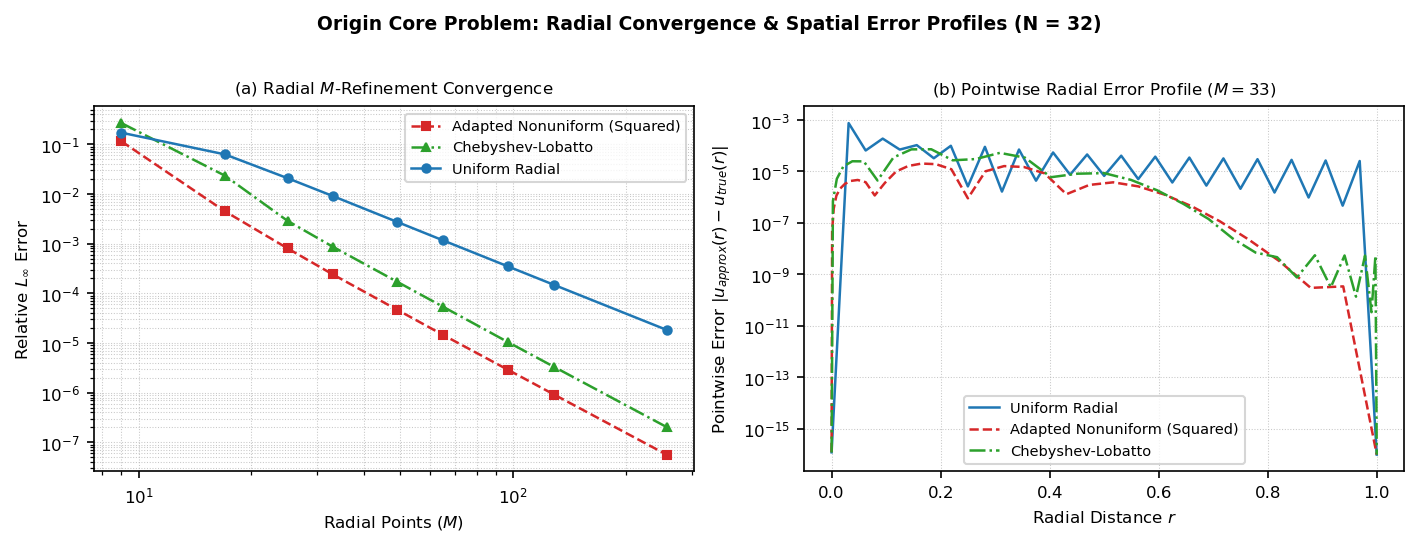

In [8]:
# Compute Radial Pointwise Error Profiles at M = 33 for Subplot (b)
M_eval = 33
results_list = []
for kind, label in rad_kinds:
    r_m = generate_custom_radial_grid(M_eval, R=R, kind=kind)
    res = run_radial_benchmark_case(N=N, M=M_eval, r_m=r_m, problem=problem, rad_kind=label, quad_rule=2)
    results_list.append(res)

# Journal-style 1 x 2 Figure: (a) Log-Log M-Refinement Convergence & (b) Semilog-Y Radial Pointwise Error Profiles
plot_combined_radial_convergence_and_profiles(
    df_fixed_n=df_fixed_n,
    results_list=results_list,
    title=f"Origin Core Problem: Radial Convergence & Spatial Error Profiles (N = {N})"
)
